# Workflow
* Data collection - Kaggle Dataset
* EDA - Descriptive Statistics, Feature distributions, etc.
* Data Preprocessing - Balancing the classes
* Train Test Split
* Model Selection
* Random forest classifier - Binary Classification problem
* Hyperparameter Tuning
* Trained Model - Best Model
* Testing the Model
* Prediction

## Importing the dependencies

In [194]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [195]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils import resample
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import pickle

* ```resample``` is imported because of the class imbalance i.e. datapoints differ.
* ```GridSearchCV``` is imported for cross validation report (Hyperparameter technique).
* ```GridSearchCV``` is better than ```RandomizedSearchCV``` but takes more time to train.
* ```pickle``` is imported to save our trained model for future predictions.

**Cross Validation Score**

* A better metric than accuracy, where we would split the dataset into, let's say 5 datasets, and try to use different splits as training and test data.
* Robust model building is ensured.

## Data Collection and Processing

In [196]:
# load the dataset to a pandas dataframe
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Machine Learning Projects/Rainfall Prediction/Rainfall.csv")

In [197]:
print(type(data))

<class 'pandas.core.frame.DataFrame'>


In [198]:
data.shape

(366, 12)

In [199]:
data.head()

,day,pressure,maxtemp,temperature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [200]:
data.tail()

,day,pressure,maxtemp,temperature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
361,27,1022.7,18.8,17.7,16.9,15.0,84,90,yes,0.0,30.0,18.4
362,28,1026.6,18.6,17.3,16.3,12.8,75,85,yes,1.0,20.0,25.9
363,29,1025.9,18.9,17.7,16.4,13.3,75,78,yes,4.6,70.0,33.4
364,30,1025.3,19.2,17.3,15.2,13.3,78,86,yes,1.2,20.0,20.9
365,31,1026.4,20.5,17.8,15.5,13.0,74,66,no,5.7,20.0,23.3


To see the unique values under a certain column, we use ```unique()```.

In [201]:
data["day"].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [202]:
print("Data Info:")
data.info()

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   day                     366 non-null    int64  
 1   pressure                366 non-null    float64
 2   maxtemp                 366 non-null    float64
 3   temperature             366 non-null    float64
 4   mintemp                 366 non-null    float64
 5   dewpoint                366 non-null    float64
 6   humidity                366 non-null    int64  
 7   cloud                   366 non-null    int64  
 8   rainfall                366 non-null    object 
 9   sunshine                366 non-null    float64
 10           winddirection  365 non-null    float64
 11  windspeed               365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB


In [203]:
data.columns

Index(['day', 'pressure ', 'maxtemp', 'temperature', 'mintemp', 'dewpoint',
       'humidity ', 'cloud ', 'rainfall', 'sunshine', '         winddirection',
       'windspeed'],
      dtype='object')

In [204]:
# remove extra  spaces in all columns
data.columns = data.columns.str.strip()

In [205]:
data.columns

Index(['day', 'pressure', 'maxtemp', 'temperature', 'mintemp', 'dewpoint',
       'humidity', 'cloud', 'rainfall', 'sunshine', 'winddirection',
       'windspeed'],
      dtype='object')

In [206]:
print("Data Info:")
data.info()

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   day            366 non-null    int64  
 1   pressure       366 non-null    float64
 2   maxtemp        366 non-null    float64
 3   temperature    366 non-null    float64
 4   mintemp        366 non-null    float64
 5   dewpoint       366 non-null    float64
 6   humidity       366 non-null    int64  
 7   cloud          366 non-null    int64  
 8   rainfall       366 non-null    object 
 9   sunshine       366 non-null    float64
 10  winddirection  365 non-null    float64
 11  windspeed      365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB


In [207]:
data = data.drop(columns=["day"])

In [208]:
data.head()

,pressure,maxtemp,temperature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [209]:
# checking the number of missing values
print(data.isnull().sum())

pressure         0
maxtemp          0
temperature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
rainfall         0
sunshine         0
winddirection    1
windspeed        1
dtype: int64


In [210]:
data["winddirection"].unique()

array([ 80.,  50.,  40.,  20.,  30.,  60.,  70.,  10., 200., 220., 120.,
       190., 210., 300., 240., 180., 230.,  90., 170., 150., 100., 130.,
        nan, 160., 270., 280., 250., 260., 290., 350., 110., 140.])

In [211]:
print(data["winddirection"].mode())

0    20.0
Name: winddirection, dtype: float64


In [212]:
data['windspeed'].median()

20.5

### Handling the missing values
* ```winddirection``` is a categorical variable, so mode makes more sense for filling the missing values.
* ```windspeed``` is a numerical continuous variable and thus the median as a replacement for null values make more sense.

In [213]:
# handling the missing values
data["winddirection"] = data["winddirection"].fillna(data["winddirection"].mode()[0])
data["windspeed"] = data["windspeed"].fillna(data["windspeed"].median())

In [214]:
# checking the number of missing values
print(data.isnull().sum())

pressure         0
maxtemp          0
temperature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
rainfall         0
sunshine         0
winddirection    0
windspeed        0
dtype: int64


**Label Encoding**

In [215]:
data["rainfall"].unique()

array(['yes', 'no'], dtype=object)

In [216]:
# converting the yes & no to 1 and 0 respectively
data["rainfall"] = data["rainfall"].map({"yes": 1, "no": 0})

In [217]:
data.head()

,pressure,maxtemp,temperature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,19.9,18.3,16.8,13.1,72,49,1,9.3,80.0,26.3
1,1022.0,21.7,18.9,17.2,15.6,81,83,1,0.6,50.0,15.3
2,1019.7,20.3,19.3,18.0,18.4,95,91,1,0.0,40.0,14.2
3,1018.9,22.3,20.6,19.1,18.8,90,88,1,1.0,50.0,16.9
4,1015.9,21.3,20.7,20.2,19.9,95,81,1,0.0,40.0,13.7


## Exploratory Data Analysis (EDA)

In [218]:
data.shape

(366, 11)

In [219]:
# setting plot style for all the plots
sns.set(style="whitegrid")

In [220]:
data.describe()

,pressure,maxtemp,temperature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,1013.742623,26.191257,23.747268,21.894536,19.989071,80.177596,71.128415,0.680328,4.419399,101.284153,21.534153
std,6.414776,5.978343,5.632813,5.594153,5.997021,10.062470,21.798012,0.466988,3.934398,81.722827,10.056054
min,998.500000,7.100000,4.900000,3.100000,-0.400000,36.000000,0.000000,0.000000,0.000000,10.000000,4.400000
25%,1008.500000,21.200000,18.825000,17.125000,16.125000,75.000000,58.000000,0.000000,0.500000,40.000000,13.725000
50%,1013.000000,27.750000,25.450000,23.700000,21.950000,80.500000,80.000000,1.000000,3.500000,70.000000,20.500000
75%,1018.100000,31.200000,28.600000,26.575000,25.000000,87.000000,88.000000,1.000000,8.200000,190.000000,27.825000
max,1034.600000,36.300000,32.400000,30.000000,26.700000,98.000000,100.000000,1.000000,12.100000,350.000000,59.500000


* If the mean and median values are close to each other then it signifies that dataset follows normal distribution else it is skewed.
* 50th percentile is the median.

In [221]:
print(data.columns)

Index(['pressure', 'maxtemp', 'temperature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'rainfall', 'sunshine', 'winddirection', 'windspeed'],
      dtype='object')


* The distribution plot is plotted for numerical variables.

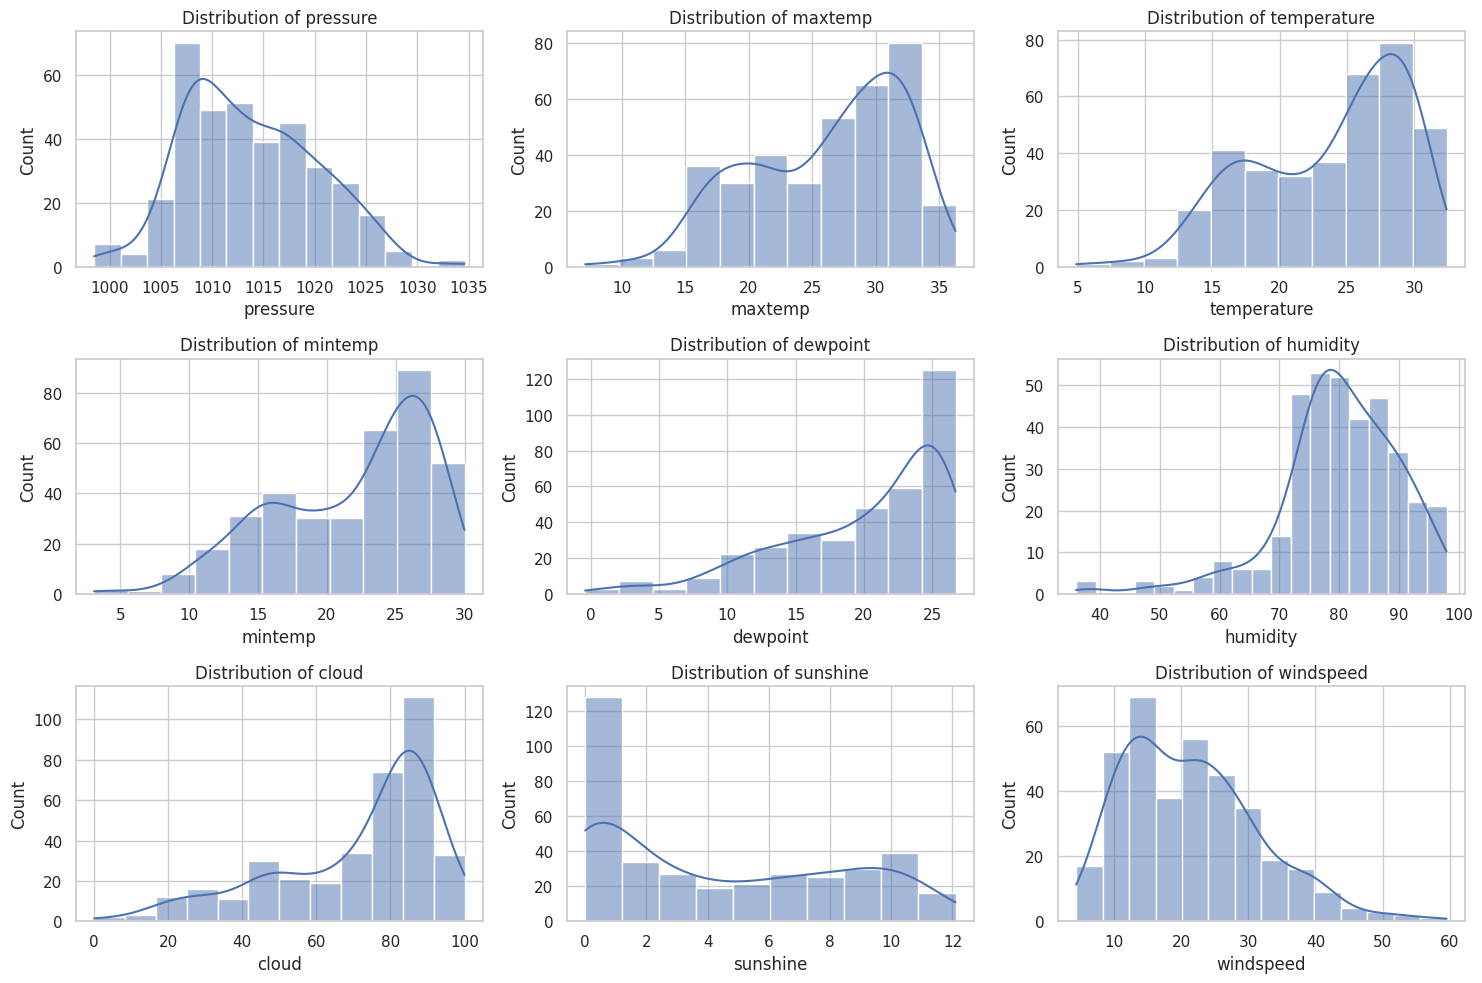

In [222]:
plt.figure(figsize=(15, 10))

for i, column in enumerate(['pressure', 'maxtemp', 'temperature', 'mintemp', 'dewpoint', 'humidity','cloud', 'sunshine', 'windspeed'], 1):
  plt.subplot(3, 3, i)
  sns.histplot(data[column], kde=True)
  plt.title(f"Distribution of {column}")

plt.tight_layout()
plt.show()

* ```enumerate``` is used when we have to keep track of the indices too.
* In the above loop, ```i``` is the index and ```column``` denotes the elements of the list.
* The parameter passed in ```enumerate``` is the starting value of the index (here it is 1).
* ```subplot``` in 3 rows and 3 columns with 1st position of ```pressure```, 2nd of ```maxtemp``` and so on.
* The whole plot is made in a grid of 3 by 3 and the index gives the location of the plot of that particular index.
* ```kde``` argument means Kernel Density Function, which shows a smooth distribution curve over the bars.

* If working with SVC, Logistic Regression, we need to standardize the data using ```standard_scalar```.
* They work in uniform distribution only.
* Tree based model is a non-linear model so no need of normalization.

## Distribution of Rainfall column

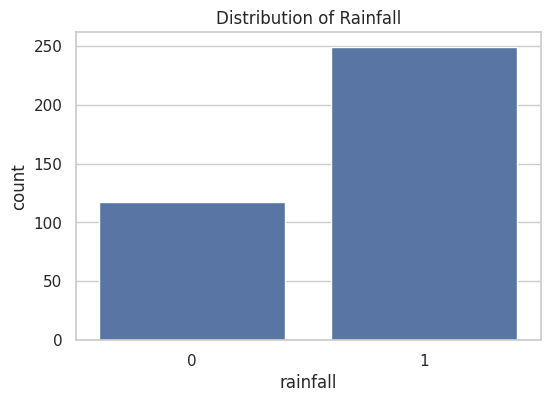

In [223]:
plt.figure(figsize=(6, 4))
sns.countplot(x="rainfall", data=data)
plt.title("Distribution of Rainfall")
plt.show()

* From above chart, it is quite clear that there is a class distribution imbalance.
* The ```yes``` values are 250 whereas ```no``` values are about 120. There is a huge difference.

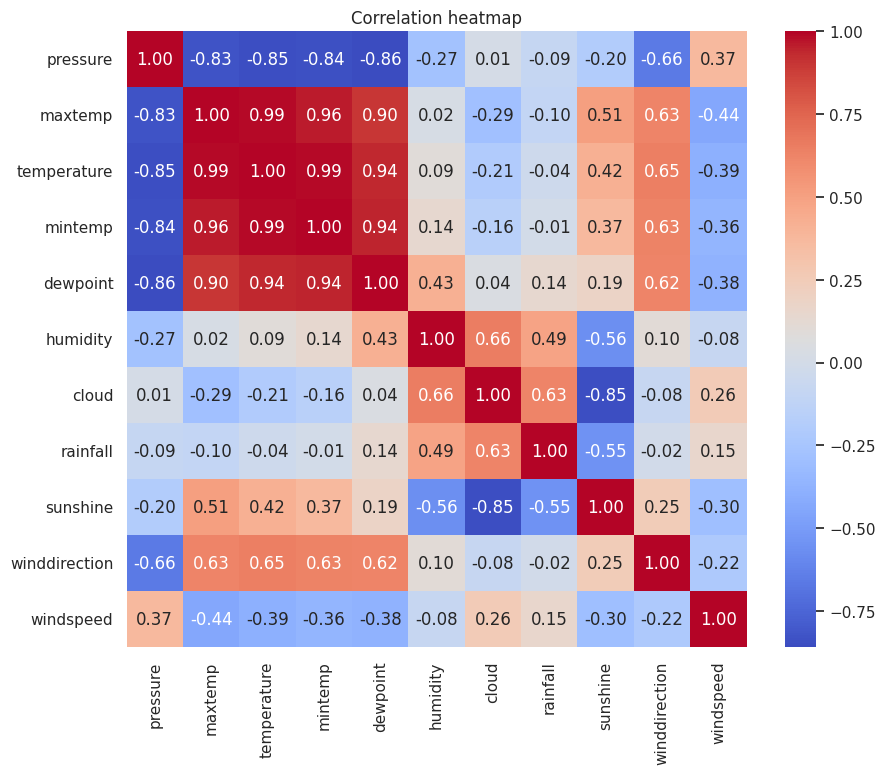

In [224]:
# correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation heatmap")
plt.show()

* 1 represents, direct correlation. The factor by which one variable is increased, the another variable having a correlation coefficient as 1 will also increase by same factor.
* Negative correlation means the relationship is inverse.
* We need to avoid multi-collinearity. So we take only one highly correlated column other than itself to avoid this situation (```mintemp``` considered).
* Now we don't have several columns contributing to the same target variable.

### Plotting a boxplot
* It helps us understand the presence of outliers in the data.

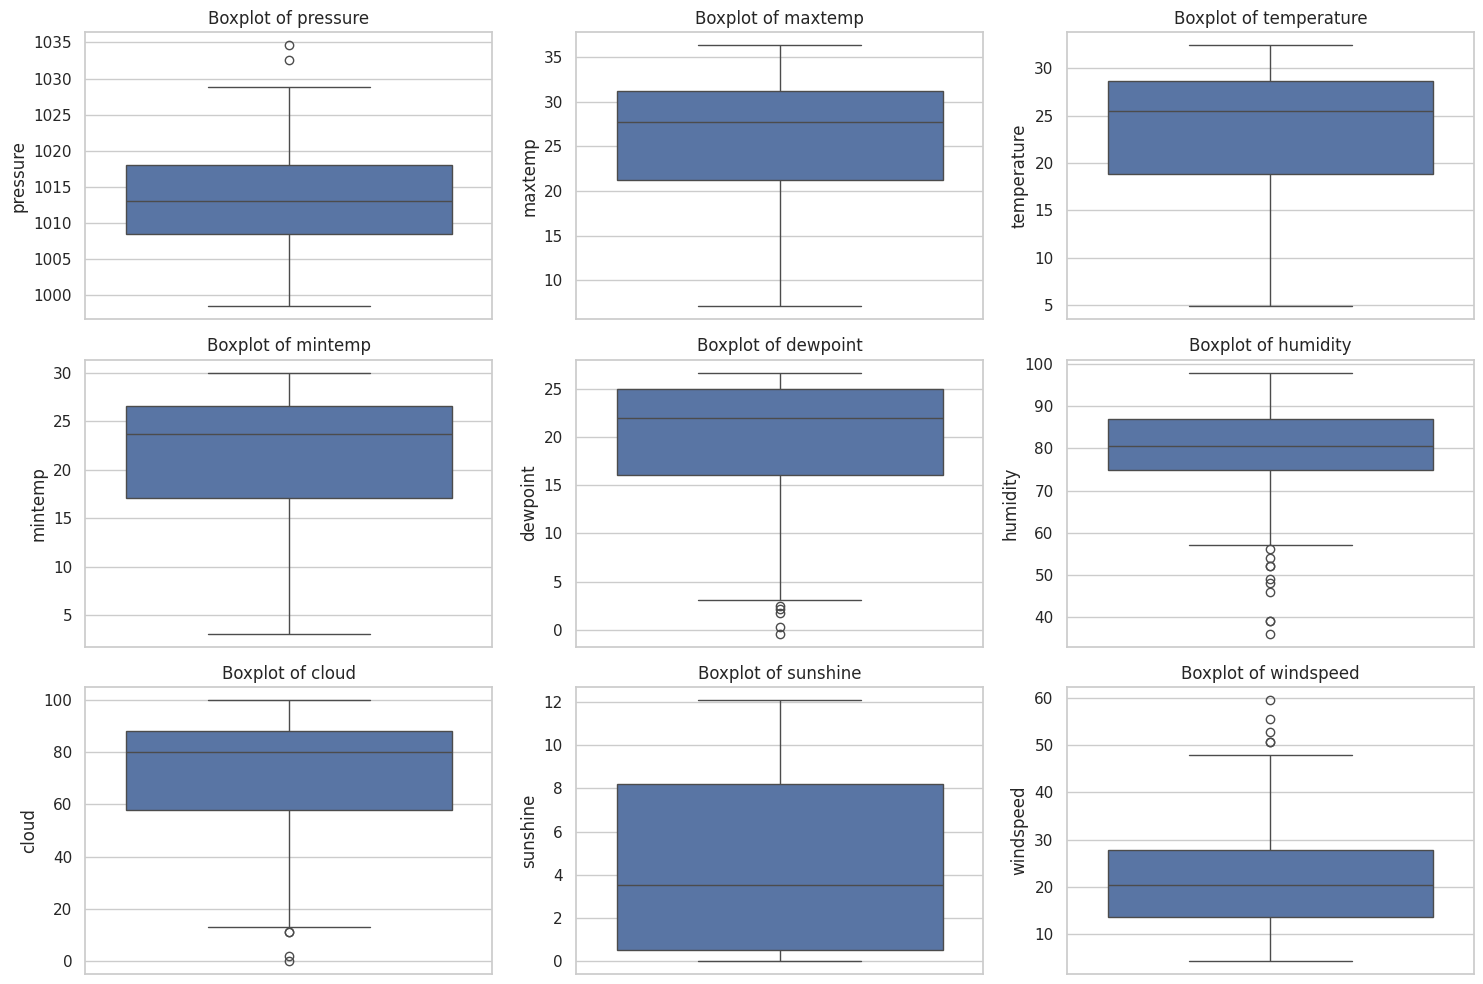

In [225]:
plt.figure(figsize=(15, 10))

for i, column in enumerate(['pressure', 'maxtemp', 'temperature', 'mintemp', 'dewpoint', 'humidity','cloud', 'sunshine', 'windspeed'], 1):
  plt.subplot(3, 3, i)
  sns.boxplot(data[column])
  plt.title(f"Boxplot of {column}")

plt.tight_layout()
plt.show()

## Data Preprocessing

In [226]:
# dropping the highly correlated column
data = data.drop(columns=['maxtemp', 'temperature', 'dewpoint'])

In [227]:
data.head()

,pressure,mintemp,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,16.8,72,49,1,9.3,80.0,26.3
1,1022.0,17.2,81,83,1,0.6,50.0,15.3
2,1019.7,18.0,95,91,1,0.0,40.0,14.2
3,1018.9,19.1,90,88,1,1.0,50.0,16.9
4,1015.9,20.2,95,81,1,0.0,40.0,13.7


### Downsampling
* To have balanced class of 1 and 0 for ```rainfall``` column.

In [228]:
# to know which is the majority and minority class
print(data["rainfall"].value_counts())

rainfall
1    249
0    117
Name: count, dtype: int64


* We will take only 117 rows of rainfall 1 case to have a balance.

In [229]:
# separate majority and minority class
df_majority = data[data["rainfall"] == 1]
df_minority = data[data["rainfall"] == 0]

In [230]:
print(df_majority.shape)
print(df_minority.shape)

(249, 8)
(117, 8)


In [231]:
# downsample majority class to match minority count
df_majority_downsampled = resample(df_majority, replace=False, n_samples=len(df_minority), random_state=42)

* ```replace = False``` means avoid taking duplicate values.
* ```n_samples``` refers to the length of downsampling or the number of datapoints needed.

In [232]:
print(df_majority_downsampled.shape)

(117, 8)


In [233]:
# concatenating (joining rows) the downsampled and the minority dataset
df_downsampled = pd.concat([df_majority_downsampled, df_minority])

* The concatenation ensure the adding but not the shuffling.

In [234]:
df_downsampled.shape

(234, 8)

In [235]:
df_downsampled.head()

,pressure,mintemp,humidity,cloud,rainfall,sunshine,winddirection,windspeed
188,1005.9,27.9,77,53,1,10.5,270.0,11.3
9,1017.5,17.2,85,91,1,0.0,70.0,37.7
137,1012.3,23.2,80,86,1,0.3,80.0,39.5
89,1018.3,18.4,79,89,1,2.4,40.0,14.8
157,1008.8,24.8,91,80,1,2.2,20.0,11.2


In [236]:
# shuffle the final dataframe
df_downsampled = df_downsampled.sample(frac=1, random_state=42).reset_index(drop=True)

* ```frac=1``` not dropping any rows, and shuffling.

In [237]:
df_downsampled.head()

,pressure,mintemp,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1022.2,17.0,78,90,1,0.0,30.0,28.5
1,1013.4,23.6,69,17,0,10.5,70.0,12.4
2,1006.1,27.6,74,27,0,10.8,220.0,8.7
3,1007.6,26.7,85,84,1,1.8,70.0,34.8
4,1021.2,12.3,66,18,0,10.1,20.0,24.4


In [238]:
# checking if the downsampling is correct
df_downsampled["rainfall"].value_counts()

,count
rainfall,
1,117
0,117


### Splitting the data

In [239]:
# splitting the features and target as X and y
X = df_downsampled.drop(columns=["rainfall"])
y = df_downsampled["rainfall"]

In [240]:
print(X)

     pressure  mintemp  humidity  cloud  sunshine  winddirection  windspeed
0      1022.2     17.0        78     90       0.0           30.0       28.5
1      1013.4     23.6        69     17      10.5           70.0       12.4
2      1006.1     27.6        74     27      10.8          220.0        8.7
3      1007.6     26.7        85     84       1.8           70.0       34.8
4      1021.2     12.3        66     18      10.1           20.0       24.4
..        ...      ...       ...    ...       ...            ...        ...
229    1008.1     26.3        86     75       5.7           20.0        9.5
230    1010.1     20.1        91     89       0.0           70.0       31.8
231    1020.6     14.6        91     88       0.3           50.0       24.4
232    1008.3     26.8        74     29       5.7           10.0        4.4
233    1005.0     25.6        87     82       2.2          160.0       12.6

[234 rows x 7 columns]


In [241]:
print(y)

0      1
1      0
2      0
3      1
4      0
      ..
229    1
230    1
231    1
232    0
233    1
Name: rainfall, Length: 234, dtype: int64


In [242]:
# splitting the data into training data and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Training

In [243]:
rf_model = RandomForestClassifier(random_state=42)

# Parameters is a dictionary
param_grid_rf = {
    "n_estimators": [50, 100, 200], # number of trees
    "max_features": ["sqrt", "log2"],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

* ```random_state``` ensures reprodicibility. It splits into a specific way.

## Calling ```GridSearchCV``` for Hyperparameter tuning

In [244]:
# Hypertuning using GridSearchCV
grid_search_rf = GridSearchCV(estimator=rf_model, param_grid=param_grid_rf, cv=5, n_jobs=-1, verbose=2)

grid_search_rf.fit(X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             verbose=2)

* ```cv = 5``` means 4 folds will go in training and 1 in test.
* ```n_jobs=-1``` means to use all the processors.
* ```verbose = 2``` gives info on how the training is happening.

* Which combination of parameters gave highest accuracy.

In [245]:
best_rf_model = grid_search_rf.best_estimator_

print("best parameters for Random Forest:", grid_search_rf.best_params_)

best parameters for Random Forest: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 50}


* ```grid_search_rf.best_estimator_``` gives the best model.
* ```grid_search_rf.best_params``` gives the best set of parameters.

## Model Evaluation

In [246]:
cv_scores = cross_val_score(best_rf_model, X_train, y_train, cv=5)
print("Cross-validation scores:", cv_scores)
print("Mean cross-validation score:", np.mean(cv_scores))

Cross-validation scores: [0.68421053 0.84210526 0.83783784 0.81081081 0.91891892]
Mean cross-validation score: 0.8187766714082503


In [247]:
# test set performance
y_pred = best_rf_model.predict(X_test)

print("Test set Accuracy:", accuracy_score(y_test, y_pred))
print("Test set Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Test set Accuracy: 0.7659574468085106
Test set Confusion Matrix:
 [[17  7]
 [ 4 19]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.71      0.76        24
           1       0.73      0.83      0.78        23

    accuracy                           0.77        47
   macro avg       0.77      0.77      0.77        47
weighted avg       0.77      0.77      0.77        47



## Prediction on unknown data

In [248]:
print(X_train.columns)

Index(['pressure', 'mintemp', 'humidity', 'cloud', 'sunshine', 'winddirection',
       'windspeed'],
      dtype='object')


In [249]:
# chose `mintemp``` to avoid multi-collinearity
input_data = (1015.9, 20.2, 95, 81, 0.0, 40.0, 13.7)

input_df = pd.DataFrame([input_data], columns=['pressure', 'mintemp', 'humidity', 'cloud', 'sunshine','winddirection', 'windspeed'])

In [250]:
input_df

,pressure,mintemp,humidity,cloud,sunshine,winddirection,windspeed
0,1015.9,20.2,95,81,0.0,40.0,13.7


In [251]:
prediction = best_rf_model.predict(input_df) # list as output
print("Prediction result:", "Rainfall" if prediction[0] == 1 else "No Rainfall")

Prediction result: Rainfall


In [252]:
# save model and feature names to a pickle file
model_data = {"model": best_rf_model, "feature_names": X.columns.tolist()}

with open("rainfall_prediction_model.pkl", "wb") as file:
  pickle.dump(model_data, file)

## Load the saved model file and use it for prediction

In [253]:
import pickle
import pandas as pd

In [254]:
# load the trained model and feature names from the pickle file
with open("rainfall_prediction_model.pkl", "rb") as file:
  model_data = pickle.load(file)

In [255]:
# unpacking
model = model_data["model"]
feature_names = model_data["feature_names"]

In [256]:
input_data = (1015.9, 20.2, 95, 81, 0.0, 40.0, 13.7)

input_df = pd.DataFrame([input_data], columns=feature_names)

In [257]:
prediction = best_rf_model.predict(input_df)
print("Prediction result:", "Rainfall" if prediction[0] == 1 else "No Rainfall")

Prediction result: Rainfall


## To Try:
1. SMOTE for class balancing
2. PCA for dimensionality reduction
3. Simpler models like Logistic Regression (with Feature scaling)
4. Model Selection with hyperparameter tuning
5. Training on Naive-Bayes Classifier
6. RandomSearchCV